# QM9 HOMO-LUMO Gap Prediction
## Geometry Matters: 2D MPNNs vs. E(3)-Equivariant Models
### CMU 24-788 · Solo student · Bonus submission (Baseline + 2 contributions)

## Install Dependencies

In [ ]:
import os

import torch
print('PyTorch version :', torch.__version__)
print('CUDA available  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU             :', torch.cuda.get_device_name(0))

torch_ver = torch.__version__.split('+')[0]   
cuda_tag  = 'cpu'
if torch.cuda.is_available():
    cu       = torch.version.cuda.replace('.', '')  
    cuda_tag = 'cu' + cu

wheel_url = 'https://data.pyg.org/whl/torch-' + torch_ver + '+' + cuda_tag + '.html'
print('Wheel URL:', wheel_url)

print('\nInstalling torch_geometric ...')
os.system('pip install -q torch_geometric')

print('Installing torch_scatter and torch_sparse ...')
os.system('pip install torch_scatter torch_sparse -f ' + wheel_url)

print('Installing scikit-learn, matplotlib, pandas, tqdm ...')
os.system('pip install -q scikit-learn matplotlib pandas tqdm')

import torch_geometric
from torch_scatter import scatter
print('torch_geometric :', torch_geometric.__version__)
print('torch_scatter   : OK')
print('All dependencies ready!')


PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
Wheel URL: https://data.pyg.org/whl/torch-2.10.0+cu128.html

Installing torch_geometric ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.1 MB/s eta 0:00:00
Installing torch_scatter and torch_sparse ...
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 88.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 125.3 MB/s eta 0:00:00
Installing scikit-learn, matplotlib, pandas, tqdm ...
torch_geometric : 2.7.0
torch_scatter   : OK
All dependencies ready!


## Configuration

In [ ]:
import os, csv, time, copy, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
import torch_geometric.transforms as T
from torch_geometric.nn import NNConv, Set2Set, global_add_pool
from torch_scatter import scatter

QUICK_RUN   = False   # True = 5 epochs, 5k train  |  False = full run

# Main configuration
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_ROOT   = './data'
CKPT_DIR    = './checkpoints'
OUT_DIR     = './outputs'
TARGET_IDX  = 4          # HOMO-LUMO gap (Δε), stored in eV by QM9
EV_TO_MEV   = 1000.0
SEED        = 42

# Full-run split (SchNet paper)
N_TRAIN     = 5_000 if QUICK_RUN else 110_000
N_VAL       = 1_000 if QUICK_RUN else  10_000
N_TEST      = 1_000 if QUICK_RUN else  10_000

# Training the hyperparameters
EPOCHS      = 5   if QUICK_RUN else 100
BATCH_SIZE  = 32
LR          = 5e-4
PATIENCE    = 5   if QUICK_RUN else 20
NUM_WORKERS = 2

# Contribution 2: learning curve subset sizes
# Each trains for LC_EPOCHS; we report val MAE at the end
LC_SIZES    = [1_000, 5_000] if QUICK_RUN else [1_000, 5_000, 10_000, 25_000, 50_000, 110_000]
LC_EPOCHS   = 3  if QUICK_RUN else 50   # enough to see the trend without full training

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(OUT_DIR,  exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)

mode = 'QUICK TEST' if QUICK_RUN else 'FULL RUN'
print(f'Mode     : {mode}')
print(f'Device   : {DEVICE}')
print(f'Epochs   : {EPOCHS}  |  Train size: {N_TRAIN:,}  |  Patience: {PATIENCE}')
print(f'LC sizes : {LC_SIZES}  ({LC_EPOCHS} epochs each)')

Mode     : FULL RUN
Device   : cuda
Epochs   : 100  |  Train size: 110,000  |  Patience: 20
LC sizes : [1000, 5000, 10000, 25000, 50000, 110000]  (50 epochs each)


## Dataset

In [ ]:
class SelectTarget:
    """Keep only the HOMO-LUMO gap target column."""
    def __init__(self, idx=TARGET_IDX):
        self.idx = idx
    def __call__(self, data):
        data.y = data.y[:, self.idx].unsqueeze(1)   # shape (1, 1)
        return data

print('Downloading loading QM9')
full_dataset = QM9(root=DATA_ROOT, transform=T.Compose([SelectTarget()]))

# Deterministic shuffle then split
torch.manual_seed(SEED)
full_dataset = full_dataset.shuffle()
train_ds_full = full_dataset[:N_TRAIN]
val_ds        = full_dataset[N_TRAIN : N_TRAIN + N_VAL]
test_ds       = full_dataset[N_TRAIN + N_VAL : N_TRAIN + N_VAL + N_TEST]

# Compute normalisation stats on the FULL training set targets
ys_full = torch.cat([d.y for d in train_ds_full], dim=0)
MEAN    = ys_full.mean().item()
STD     = ys_full.std().item()
MEAN_T  = torch.tensor(MEAN, device=DEVICE)
STD_T   = torch.tensor(STD,  device=DEVICE)

val_loader  = DataLoader(val_ds,  batch_size=64, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

print(f'Train: {len(train_ds_full):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}')
print(f'Target mean = {MEAN*EV_TO_MEV:.1f} meV  |  std = {STD*EV_TO_MEV:.1f} meV')
s = train_ds_full[0]
print(f'Node feat dim: {s.x.shape[1]}  |  Edge feat dim: {s.edge_attr.shape[1]}  |  Pos: {s.pos.shape}')

Extracting data/raw/qm9_v3.zip
Processing...
Using a pre-processed version of the dataset. Please install 'rdkit' to alternatively process the raw data.
Done!


Train: 110,000  Val: 10,000  Test: 10,000
Target mean = 6858.0 meV  |  std = 1283.1 meV
Node feat dim: 11  |  Edge feat dim: 4  |  Pos: torch.Size([21, 3])


## Model Definitions

### Baseline: MPNN (Gilmer et al. 2017)
Uses **only** 2D covalent bond graph. 3D coordinates deliberately excluded.
Inductive bias: molecular property can be inferred from topology + atom types alone.

In [4]:
class EdgeNetwork(nn.Module):
    """Maps edge features to a weight matrix for NNConv."""
    def __init__(self, edge_dim, node_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(edge_dim, 64), nn.ReLU(),
            nn.Linear(64, node_dim * node_dim),
        )
        self.node_dim = node_dim
    def forward(self, e):
        return self.net(e).view(-1, self.node_dim, self.node_dim)


class MPNNBaseline(nn.Module):
    """
    Message-Passing Neural Network baseline (Gilmer et al. 2017, NeurIPS).
    Architecture: NNConv message passing + Set2Set global readout.
    Input: 2D molecular graph (no 3D coordinates).
    """
    def __init__(self, node_in=11, edge_in=4, hidden=64, n_layers=3):
        super().__init__()
        self.node_emb = nn.Linear(node_in, hidden)
        self.convs = nn.ModuleList([
            NNConv(hidden, hidden, EdgeNetwork(edge_in, hidden), aggr='mean')
            for _ in range(n_layers)
        ])
        self.set2set = Set2Set(hidden, processing_steps=3)
        self.mlp = nn.Sequential(
            nn.Linear(2 * hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def _encode(self, data):
        h = F.relu(self.node_emb(data.x.float()))
        for conv in self.convs:
            h = F.relu(conv(h, data.edge_index, data.edge_attr.float()))
        return self.set2set(h, data.batch)     # (B, 2*hidden)

    def forward(self, data):
        return self.mlp(self._encode(data))    # (B, 1)

    def embed(self, data):
        return self._encode(data)              # graph-level embedding for analysis


m = MPNNBaseline()
print(f'MPNN parameters: {sum(p.numel() for p in m.parameters()):,}')

MPNN parameters: 870,913


### Contribution 1: EGNN (Satorras, Hoogeboom & Welling, ICML 2021)
Incorporates 3D atomic coordinates. Messages depend on interatomic distances,
making the model **E(3)-equivariant** (invariant to rotations and translations).
Hypothesis: equivariance aligns with quantum mechanics, yielding lower error.

In [5]:
class EGNNLayer(nn.Module):
    """
    Single EGNN layer. Messages depend on ||xi - xj||^2 (distance-based),
    producing E(3)-equivariant node updates. No spherical harmonics needed.
    """
    def __init__(self, hidden, edge_attr_dim=4):
        super().__init__()
        # Message: (h_i, h_j, dist^2, edge_attr) -> m_ij
        self.phi_e = nn.Sequential(
            nn.Linear(2*hidden + 1 + edge_attr_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
        )
        # Coordinate update: scalar weight per message (equivariant)
        self.phi_x = nn.Sequential(
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 1, bias=False),
        )
        # Node update: (h_i, aggregated_messages) -> h_i_new
        self.phi_h = nn.Sequential(
            nn.Linear(2*hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden),
        )

    def forward(self, h, pos, edge_index, edge_attr):
        row, col = edge_index
        diff    = pos[row] - pos[col]                               # (E, 3)
        dist_sq = (diff**2).sum(dim=-1, keepdim=True)               # (E, 1)

        m_ij  = self.phi_e(torch.cat([h[row], h[col],
                                      dist_sq, edge_attr], dim=-1)) # (E, H)
        # Equivariant coordinate update
        w       = self.phi_x(m_ij)                                  # (E, 1)
        agg_pos = scatter(diff * w, col, dim=0,
                          dim_size=h.size(0), reduce='mean')         # (N, 3)
        pos_new = pos + agg_pos

        # Node feature update with residual
        agg_m = scatter(m_ij, col, dim=0,
                        dim_size=h.size(0), reduce='mean')           # (N, H)
        h_new = self.phi_h(torch.cat([h, agg_m], dim=-1)) + h
        return h_new, pos_new


class EGNNModel(nn.Module):
    """
    Full EGNN for molecular property prediction.
    use_pos=False zeroes all coordinates (ablation variant).
    """
    def __init__(self, node_in=11, edge_in=4, hidden=128, n_layers=4, use_pos=True):
        super().__init__()
        self.use_pos  = use_pos
        self.node_emb = nn.Linear(node_in, hidden)
        self.layers   = nn.ModuleList([
            EGNNLayer(hidden, edge_attr_dim=edge_in) for _ in range(n_layers)
        ])
        self.readout  = nn.Sequential(
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 1),
        )

    def _encode(self, data):
        h   = F.silu(self.node_emb(data.x.float()))
        pos = data.pos.float()
        if not self.use_pos:
            pos = torch.zeros_like(pos)
        for layer in self.layers:
            h, pos = layer(h, pos, data.edge_index, data.edge_attr.float())
        return global_add_pool(h, data.batch)   # (B, hidden)

    def forward(self, data):
        return self.readout(self._encode(data))

    def embed(self, data):
        return self._encode(data)


eg = EGNNModel()
print(f'EGNN parameters (full)  : {sum(p.numel() for p in eg.parameters()):,}')
print(f'EGNN parameters (no pos): {sum(p.numel() for p in EGNNModel(use_pos=False).parameters()):,}')

EGNN parameters (full)  : 482,561
EGNN parameters (no pos): 482,561


## Core Training & Evaluation Functions

In [ ]:
def evaluate(model, loader, mean=MEAN, std=STD, device=DEVICE):
    """
    Evaluate a model on a DataLoader.
    Returns: MAE (meV), RMSE (meV), R², all predictions (eV), all targets (eV).
    """
    model.eval()
    preds_all, tgts_all = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out   = model(batch) * std + mean        
            preds_all.append(out.cpu())
            tgts_all.append(batch.y.cpu())

    p = torch.cat(preds_all).squeeze()
    t = torch.cat(tgts_all).squeeze()
    mae  = (p - t).abs().mean().item() * EV_TO_MEV
    rmse = ((p - t)**2).mean().sqrt().item() * EV_TO_MEV
    r2   = (1 - ((t - p)**2).sum() / ((t - t.mean())**2).sum()).item()
    return mae, rmse, r2, p, t


def train_model(model, name, train_ds, epochs=EPOCHS, lr=LR,
                patience=PATIENCE, save_ckpt=True, verbose=True):

    model     = model.to(DEVICE)
    opt       = Adam(model.parameters(), lr=lr, weight_decay=1e-8)
    sched     = CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    crit      = nn.L1Loss()
    ckpt_path = os.path.join(CKPT_DIR, f'{name}_best.pt')

    train_loader_local = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    best_val, patience_ctr = float('inf'), 0
    log_rows, best_state   = [], None

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, t0 = 0.0, time.time()

        for batch in train_loader_local:
            batch  = batch.to(DEVICE)
            y_norm = (batch.y - MEAN_T) / STD_T
            opt.zero_grad()
            loss = crit(model(batch), y_norm)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 10.0)
            opt.step()
            total_loss += loss.item() * batch.num_graphs

        sched.step()
        train_loss = total_loss / len(train_ds)
        val_mae, val_rmse, val_r2, _, _ = evaluate(model, val_loader)
        elapsed = time.time() - t0

        log_rows.append(dict(epoch=epoch, train_loss=train_loss,
                             val_mae=val_mae, val_rmse=val_rmse,
                             val_r2=val_r2, lr=sched.get_last_lr()[0],
                             time_s=elapsed))

        if verbose and (epoch % 10 == 0 or epoch == 1):
            print(f'  [{name}] ep {epoch:3d} | loss={train_loss:.4f} '
                  f'| val MAE={val_mae:.1f} meV | R²={val_r2:.3f} | {elapsed:.0f}s')

        if val_mae < best_val:
            best_val, patience_ctr = val_mae, 0
            best_state = copy.deepcopy(model.state_dict())
            if save_ckpt:
                torch.save({'model_state': best_state, 'epoch': epoch,
                            'mean': MEAN, 'std': STD, 'val_mae': val_mae}, ckpt_path)
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                if verbose:
                    print(f'  Early stopping at epoch {epoch}')
                break

    # Restore best weights
    model.load_state_dict(best_state)
    if verbose:
        print(f' Best val MAE: {best_val:.1f} meV')
    return best_val, pd.DataFrame(log_rows)


def load_best(model, name):
    ckpt = torch.load(os.path.join(CKPT_DIR, f'{name}_best.pt'), map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    return model.to(DEVICE)


print('Training utilities ready.')

Training utilities ready.


## Training the Baseline: MPNN (2D only)

In [7]:
print('=' * 60)
print('TRAINING: MPNN Baseline (2D graph, no 3D coordinates)')
print('=' * 60)

mpnn_model = MPNNBaseline(hidden=64, n_layers=3)
print(f'Parameters: {sum(p.numel() for p in mpnn_model.parameters()):,}')

_, log_mpnn = train_model(mpnn_model, 'mpnn', train_ds_full)
log_mpnn.to_csv(os.path.join(OUT_DIR, 'mpnn_log.csv'), index=False)

# Reload best checkpoint for final test evaluation
mpnn_model = load_best(MPNNBaseline(hidden=64, n_layers=3), 'mpnn')
mae_m, rmse_m, r2_m, preds_m, targets_ev = evaluate(mpnn_model, test_loader)
print(f'\n[MPNN TEST]  MAE={mae_m:.1f} meV  |  RMSE={rmse_m:.1f} meV  |  R²={r2_m:.4f}')

TRAINING: MPNN Baseline (2D graph, no 3D coordinates)
Parameters: 870,913
  [mpnn] ep   1 | loss=0.2787 | val MAE=280.7 meV | R²=0.897 | 84s
  [mpnn] ep  10 | loss=0.1447 | val MAE=183.4 meV | R²=0.960 | 82s
  [mpnn] ep  20 | loss=0.1248 | val MAE=166.6 meV | R²=0.966 | 81s
  [mpnn] ep  30 | loss=0.1146 | val MAE=155.2 meV | R²=0.971 | 81s
  [mpnn] ep  40 | loss=0.1070 | val MAE=149.9 meV | R²=0.973 | 82s
  [mpnn] ep  50 | loss=0.1006 | val MAE=142.1 meV | R²=0.975 | 81s
  [mpnn] ep  60 | loss=0.0952 | val MAE=139.6 meV | R²=0.975 | 81s
  [mpnn] ep  70 | loss=0.0909 | val MAE=137.4 meV | R²=0.976 | 81s
  [mpnn] ep  80 | loss=0.0874 | val MAE=135.9 meV | R²=0.976 | 82s
  [mpnn] ep  90 | loss=0.0852 | val MAE=135.5 meV | R²=0.976 | 81s
  [mpnn] ep 100 | loss=0.0843 | val MAE=135.4 meV | R²=0.976 | 81s
 Best val MAE: 135.3 meV

[MPNN TEST]  MAE=139.6 meV  |  RMSE=213.1 meV  |  R²=0.9728


## Train Contribution 1: EGNN (3D Equivariant)

**Why this counts as Contribution 1:**  
EGNN (Satorras et al. 2021, ICML) is a peer-reviewed model published as a methods contribution. It differs from MPNN by incorporating 3D coordinates through equivariant distance-based messages, a fundamentally different inductive bias (E(3) symmetry vs. 2D topology).

In [8]:
print('=' * 60)
print('TRAINING: EGNN — Contribution 1 (3D equivariant model variant)')
print('=' * 60)

egnn_model = EGNNModel(hidden=128, n_layers=4, use_pos=True)
print(f'Parameters: {sum(p.numel() for p in egnn_model.parameters()):,}')

_, log_egnn = train_model(egnn_model, 'egnn', train_ds_full)
log_egnn.to_csv(os.path.join(OUT_DIR, 'egnn_log.csv'), index=False)

egnn_model = load_best(EGNNModel(hidden=128, n_layers=4, use_pos=True), 'egnn')
mae_e, rmse_e, r2_e, preds_e, _ = evaluate(egnn_model, test_loader)
print(f'\n[EGNN TEST]  MAE={mae_e:.1f} meV  |  RMSE={rmse_e:.1f} meV  |  R²={r2_e:.4f}')

TRAINING: EGNN — Contribution 1 (3D equivariant model variant)
Parameters: 482,561
  [egnn] ep   1 | loss=0.3547 | val MAE=323.3 meV | R²=0.874 | 87s
  [egnn] ep  10 | loss=0.1368 | val MAE=173.3 meV | R²=0.966 | 86s
  [egnn] ep  20 | loss=0.1055 | val MAE=144.1 meV | R²=0.975 | 86s
  [egnn] ep  30 | loss=0.0887 | val MAE=112.2 meV | R²=0.985 | 86s
  [egnn] ep  40 | loss=0.0759 | val MAE=103.6 meV | R²=0.987 | 87s
  [egnn] ep  50 | loss=0.0649 | val MAE=93.6 meV | R²=0.989 | 86s
  [egnn] ep  60 | loss=0.0547 | val MAE=87.0 meV | R²=0.990 | 86s
  [egnn] ep  70 | loss=0.0458 | val MAE=81.6 meV | R²=0.991 | 87s
  [egnn] ep  80 | loss=0.0383 | val MAE=77.7 meV | R²=0.992 | 88s
  [egnn] ep  90 | loss=0.0334 | val MAE=76.3 meV | R²=0.992 | 88s
  [egnn] ep 100 | loss=0.0315 | val MAE=76.1 meV | R²=0.992 | 86s
  → Best val MAE: 76.1 meV

[EGNN TEST]  MAE=75.7 meV  |  RMSE=116.0 meV  |  R²=0.9919


## Core Results: Table + Figures

This section satisfies the **core evaluation** rubric for all groups:
- Quantitative results (MAE, RMSE, R²)
- Training loss curve figure
- Parity plot figure  
- Hypothesis evaluation

In [ ]:
# Table 1: Quantitative Results
print('\nTABLE 1 - Test Set Results (10k molecules)\n')
results_df = pd.DataFrame([
    {'Model': 'MPNN Baseline (2D only)',   'MAE (meV)': f'{mae_m:.1f}', 'RMSE (meV)': f'{rmse_m:.1f}', 'R²': f'{r2_m:.4f}'},
    {'Model': 'EGNN (3D equivariant)',      'MAE (meV)': f'{mae_e:.1f}', 'RMSE (meV)': f'{rmse_e:.1f}', 'R²': f'{r2_e:.4f}'},
])
print(results_df.to_string(index=False))
improvement = (mae_m - mae_e) / mae_m * 100
print(f'\nRelative MAE improvement (EGNN vs. MPNN): {improvement:.1f}%')
results_df.to_csv(os.path.join(OUT_DIR, 'test_results.csv'), index=False)


TABLE 1 — Test Set Results (10k molecules)

                  Model MAE (meV) RMSE (meV)     R²
MPNN Baseline (2D only)     139.6      213.1 0.9728
  EGNN (3D equivariant)      75.7      116.0 0.9919

Relative MAE improvement (EGNN vs. MPNN): 45.8%


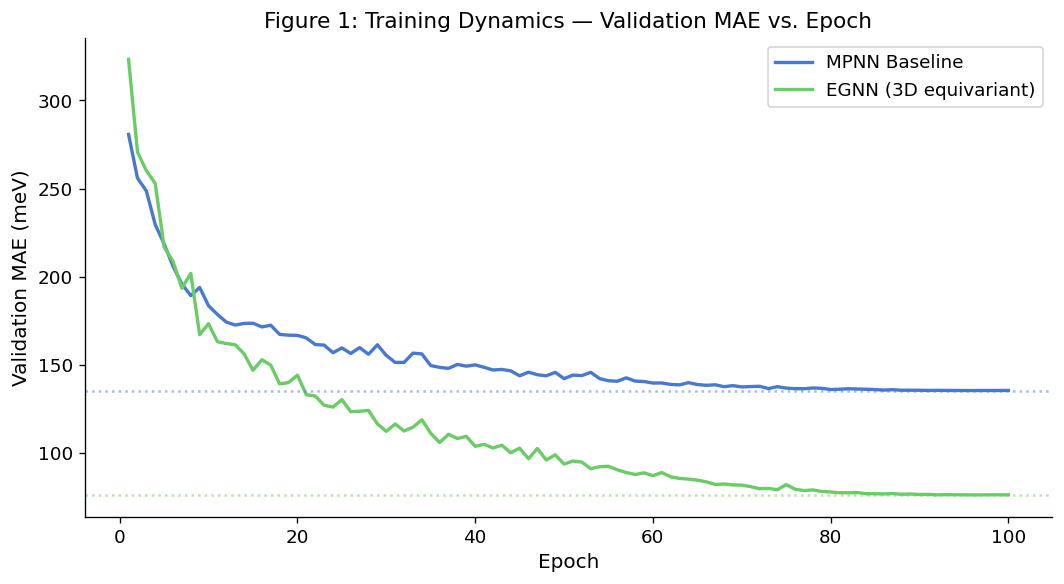

Saved: fig1_loss_curves.pdf


In [ ]:
# Figure 1: Training Loss Curves 
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(log_mpnn['epoch'], log_mpnn['val_mae'],
        label='MPNN Baseline', color='#4878CF', linewidth=2)
ax.plot(log_egnn['epoch'], log_egnn['val_mae'],
        label='EGNN (3D equivariant)', color='#6ACC65', linewidth=2)

# Mark best val MAE for each model
ax.axhline(log_mpnn['val_mae'].min(), color='#4878CF', linestyle=':', alpha=0.5)
ax.axhline(log_egnn['val_mae'].min(), color='#6ACC65', linestyle=':', alpha=0.5)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation MAE (meV)', fontsize=12)
ax.set_title('Figure 1: Training Dynamics — Validation MAE vs. Epoch', fontsize=13)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig1_loss_curves.pdf'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'fig1_loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_loss_curves.pdf')

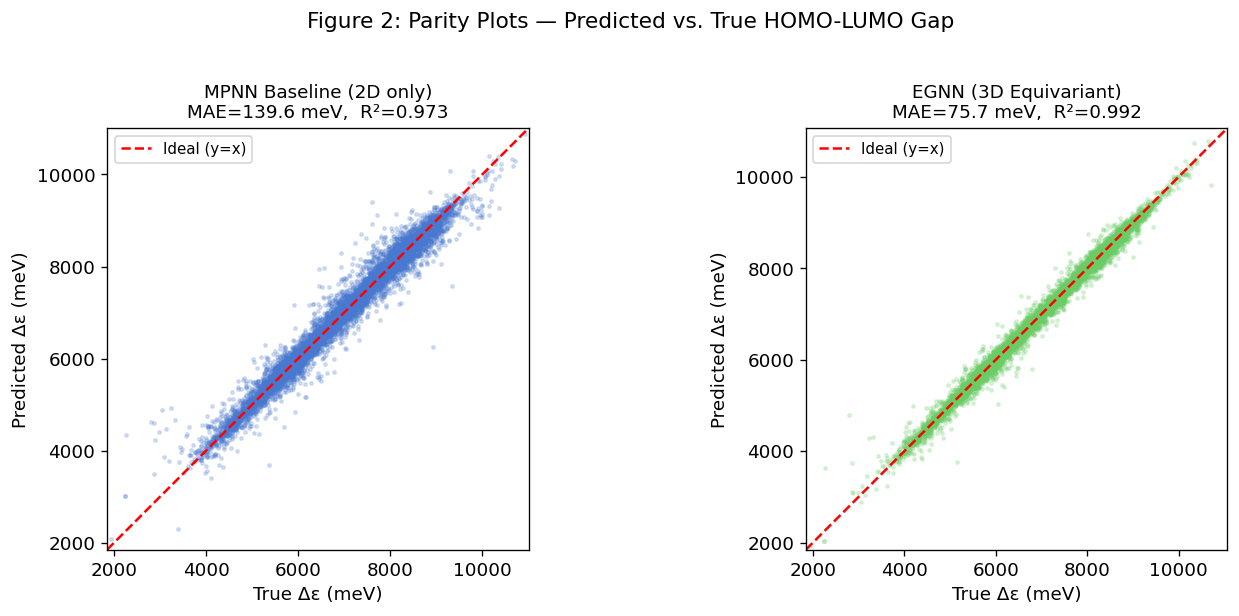

Saved: fig2_parity_plots.pdf


In [ ]:
# Figure 2: Parity Plots 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, mae, r2, title, color in zip(
    axes,
    [preds_m, preds_e],
    [mae_m, mae_e],
    [r2_m, r2_e],
    ['MPNN Baseline (2D only)', 'EGNN (3D Equivariant)'],
    ['#4878CF', '#6ACC65'],
):
    p   = preds.numpy()       * EV_TO_MEV
    t   = targets_ev.numpy()  * EV_TO_MEV
    lim = [min(t.min(), p.min()) - 80, max(t.max(), p.max()) + 80]

    ax.scatter(t, p, s=4, alpha=0.2, color=color, rasterized=True)
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='Ideal (y=x)')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('True Δε (meV)', fontsize=11)
    ax.set_ylabel('Predicted Δε (meV)', fontsize=11)
    ax.set_title(f'{title}\nMAE={mae:.1f} meV,  R²={r2:.3f}', fontsize=11)
    ax.set_aspect('equal')
    ax.legend(fontsize=9)

plt.suptitle('Figure 2: Parity Plots — Predicted vs. True HOMO-LUMO Gap', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig2_parity_plots.pdf'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'fig2_parity_plots.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_parity_plots.pdf')

## Contribution 2: Learning Curves Analysis (Category B — Training Dynamics)

**Hypothesis for Contribution 2:**  
EGNN's equivariant inductive bias should make it more *sample-efficient* than the MPNN
i.e., it should reach competitive accuracy with fewer training molecules, because the
E(3)-symmetry constraint reduces the effective hypothesis space the model must search over.

**Method:** Train each model from scratch on increasing subsets of the training data
([1k, 5k, 10k, 25k, 50k, 110k] molecules), holding val/test fixed.
Report val MAE after 50 epochs at each size. This goes far beyond comparing test-set
metrics and constitutes a standalone Category B analysis.

**Why this is a real analysis, not just a diagnostic:**  
- It has its own hypothesis (sample efficiency gap)
- It produces a standalone figure and quantitative finding
- It answers a practically important question: at what data scale does geometric encoding start to pay off?
- It mirrors the kind of analysis done in MoleculeNet (Wu et al. 2018, Figure 15) and the SchNet paper

In [12]:
print('=' * 65)
print('CONTRIBUTION 2: Learning Curves — Sample Efficiency Analysis')
print('=' * 65)
print(f'Sizes: {LC_SIZES}')
print(f'Epochs per size: {LC_EPOCHS}')
print(f'Models: MPNN Baseline, EGNN (3D equivariant)')
print()

lc_results = {name: {'sizes': [], 'val_mae': [], 'val_r2': []}
              for name in ['MPNN', 'EGNN']}

for n_train in LC_SIZES:
    print(f'--- Training size: {n_train:,} ---')

    # Subsample from the full training set (same molecules for both models)
    train_sub = train_ds_full[:n_train]

    for model_name, ModelClass, kwargs in [
        ('MPNN', MPNNBaseline, dict(hidden=64, n_layers=3)),
        ('EGNN', EGNNModel,    dict(hidden=128, n_layers=4, use_pos=True)),
    ]:
        model = ModelClass(**kwargs)
        val_mae, log_df = train_model(
            model,
            name      = f'{model_name}_lc_{n_train}',
            train_ds  = train_sub,
            epochs    = LC_EPOCHS,
            patience  = LC_EPOCHS,   # no early stopping for LC; run full budget
            save_ckpt = False,
            verbose   = False,
        )
        # Use the best val MAE from the log (not necessarily last epoch)
        best_mae = log_df['val_mae'].min()
        best_r2  = log_df.loc[log_df['val_mae'].idxmin(), 'val_r2']

        lc_results[model_name]['sizes'].append(n_train)
        lc_results[model_name]['val_mae'].append(best_mae)
        lc_results[model_name]['val_r2'].append(best_r2)

        print(f'  {model_name:4s} | n={n_train:6,} | best val MAE={best_mae:.1f} meV | R²={best_r2:.3f}')

print('\nLearning curve data collection complete.')

CONTRIBUTION 2: Learning Curves — Sample Efficiency Analysis
Sizes: [1000, 5000, 10000, 25000, 50000, 110000]
Epochs per size: 50
Models: MPNN Baseline, EGNN (3D equivariant)

--- Training size: 1,000 ---
  MPNN | n= 1,000 | best val MAE=346.2 meV | R²=0.850
  EGNN | n= 1,000 | best val MAE=388.1 meV | R²=0.828
--- Training size: 5,000 ---
  MPNN | n= 5,000 | best val MAE=255.2 meV | R²=0.910
  EGNN | n= 5,000 | best val MAE=278.6 meV | R²=0.896
--- Training size: 10,000 ---
  MPNN | n=10,000 | best val MAE=221.8 meV | R²=0.928
  EGNN | n=10,000 | best val MAE=230.3 meV | R²=0.930
--- Training size: 25,000 ---
  MPNN | n=25,000 | best val MAE=194.5 meV | R²=0.943
  EGNN | n=25,000 | best val MAE=151.2 meV | R²=0.971
--- Training size: 50,000 ---
  MPNN | n=50,000 | best val MAE=165.6 meV | R²=0.966
  EGNN | n=50,000 | best val MAE=117.3 meV | R²=0.983
--- Training size: 110,000 ---
  MPNN | n=110,000 | best val MAE=142.2 meV | R²=0.975
  EGNN | n=110,000 | best val MAE=84.6 meV | R²=0.

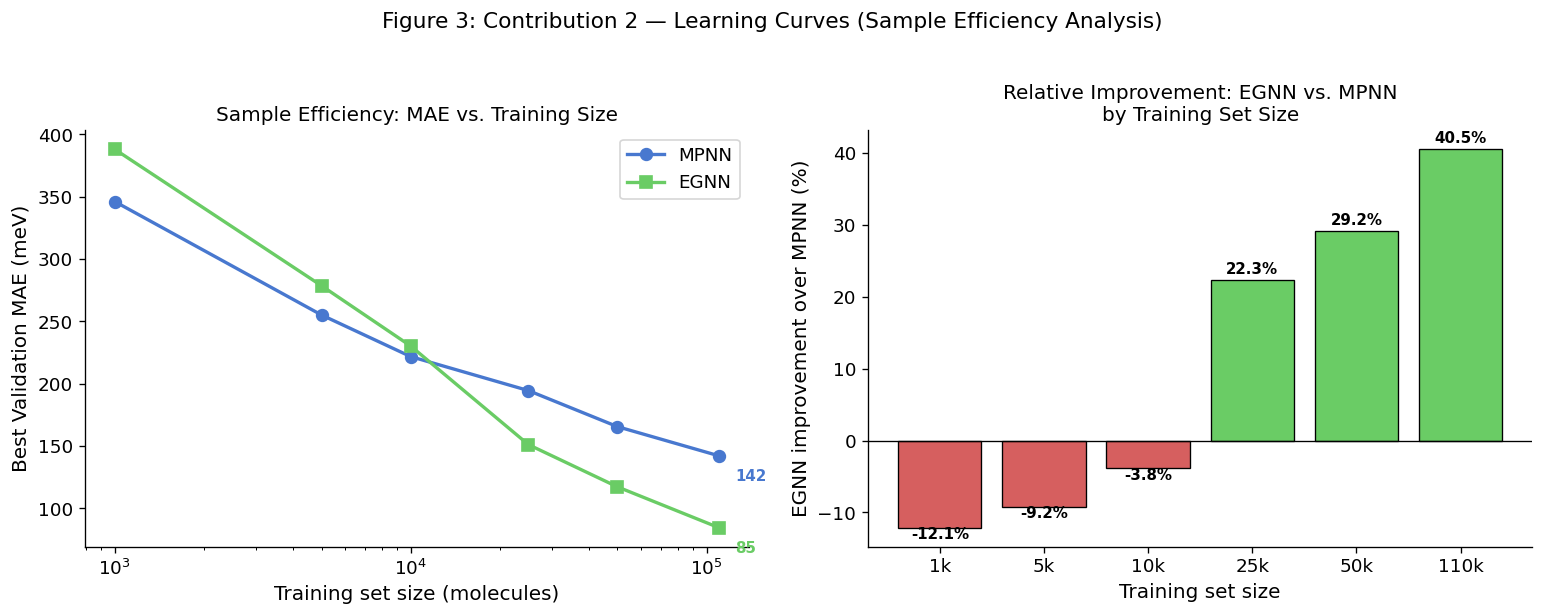

Saved: fig3_learning_curves.pdf


In [ ]:
# Figure 3: Learning Curves 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: val MAE vs. training size
ax = axes[0]
for model_name, color, marker in [
    ('MPNN', '#4878CF', 'o'),
    ('EGNN', '#6ACC65', 's'),
]:
    r = lc_results[model_name]
    ax.plot(r['sizes'], r['val_mae'], color=color, marker=marker,
            linewidth=2, markersize=7, label=model_name)
    # Annotate final point
    ax.annotate(f"{r['val_mae'][-1]:.0f}",
                xy=(r['sizes'][-1], r['val_mae'][-1]),
                xytext=(10, -15), textcoords='offset points',
                color=color, fontsize=9, fontweight='bold')

ax.set_xscale('log')
ax.set_xlabel('Training set size (molecules)', fontsize=12)
ax.set_ylabel('Best Validation MAE (meV)', fontsize=12)
ax.set_title('Sample Efficiency: MAE vs. Training Size', fontsize=12)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right panel: relative improvement of EGNN over MPNN at each size
ax2 = axes[1]
sizes_common = lc_results['MPNN']['sizes']
mpnn_maes    = lc_results['MPNN']['val_mae']
egnn_maes    = lc_results['EGNN']['val_mae']
rel_improve  = [(m - e) / m * 100 for m, e in zip(mpnn_maes, egnn_maes)]

bars = ax2.bar([str(s) if s < 1000 else f'{s//1000}k' for s in sizes_common],
               rel_improve,
               color=['#D65F5F' if r < 0 else '#6ACC65' for r in rel_improve],
               edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, rel_improve):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.5 if val >= 0 else -2),
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Training set size', fontsize=12)
ax2.set_ylabel('EGNN improvement over MPNN (%)', fontsize=12)
ax2.set_title('Relative Improvement: EGNN vs. MPNN\nby Training Set Size', fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Figure 3: Contribution 2 — Learning Curves (Sample Efficiency Analysis)',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig3_learning_curves.pdf'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'fig3_learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_learning_curves.pdf')

## t-SNE Embedding Analysis

This is visualises *why* EGNN works better.

Extracting embeddings (2000 val molecules)...
Running t-SNE (1–2 min)...


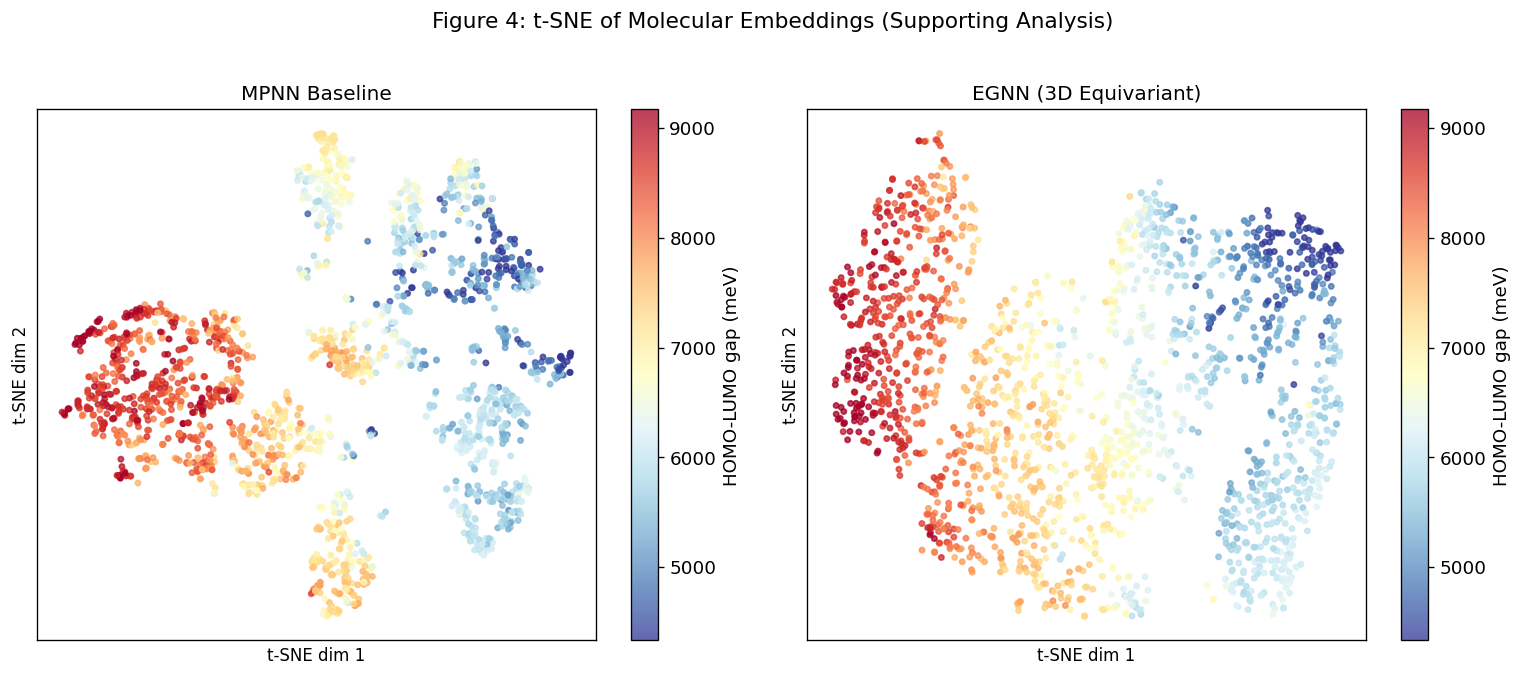

Saved: fig4_tsne.pdf


In [14]:
def extract_embeddings(model, loader, n_samples=2000):
    model.eval()
    embs, ys = [], []
    count = 0
    with torch.no_grad():
        for batch in loader:
            if count >= n_samples:
                break
            batch = batch.to(DEVICE)
            embs.append(model.embed(batch).cpu())
            ys.append(batch.y.cpu())
            count += batch.num_graphs
    embs = torch.cat(embs)[:n_samples].numpy()
    ys   = torch.cat(ys)[:n_samples].squeeze().numpy() * EV_TO_MEV
    return embs, ys


print('Extracting embeddings (2000 val molecules)...')
embs_m, ys_val = extract_embeddings(mpnn_model, val_loader)
embs_e, _      = extract_embeddings(egnn_model,  val_loader)

print('Running t-SNE (1–2 min)...')
vmin = np.percentile(ys_val, 2)
vmax = np.percentile(ys_val, 98)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, embs, title in zip(
    axes,
    [embs_m, embs_e],
    ['MPNN Baseline', 'EGNN (3D Equivariant)'],
):
    n_comp = min(50, embs.shape[1])
    pre    = PCA(n_components=n_comp, random_state=SEED).fit_transform(embs)
    proj   = TSNE(n_components=2, perplexity=30, random_state=SEED,
                  n_iter=1000).fit_transform(pre)

    sc = ax.scatter(proj[:, 0], proj[:, 1], c=ys_val,
                    cmap='RdYlBu_r', s=10, alpha=0.75,
                    vmin=vmin, vmax=vmax)
    plt.colorbar(sc, ax=ax, label='HOMO-LUMO gap (meV)')
    ax.set_xlabel('t-SNE dim 1', fontsize=10)
    ax.set_ylabel('t-SNE dim 2', fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Figure 4: t-SNE of Molecular Embeddings (Supporting Analysis)',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig4_tsne.pdf'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'fig4_tsne.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_tsne.pdf')